# EDA Plots for ADANA Breast Cancer Cohort Metadata

CosMx SMI 6K-plex spatial transcriptomics study.

In [17]:
# ============================================================
# SETUP & CONFIGURATION
# ============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(patchwork)
  library(scales)
  library(forcats)
})

HAS_COMPLEXUPSET <- tryCatch({
  library(ComplexUpset)
  TRUE
}, error = function(e) FALSE)
cat("ComplexUpset available:", HAS_COMPLEXUPSET, "\n")

# ── Configurable parameters ──
INPUT_FILE       <- "../inputs/sample_metadata_details.csv"
RECEPTOR_SOURCE  <- "path"           # "path" or "registry"
OUTPUT_DIR       <- file.path("../outputs", "METADATA", "figures")
SAVE_PLOTS       <- TRUE
PLOT_FORMAT      <- "pdf"            # "pdf" or "png"
DPI              <- 300
BASE_TEXT_SIZE   <- 7

# ── Color palettes ──
PAL_BINARY   <- c("Yes" = "#2c7bb6", "No" = "#d7191c")
PAL_RECEPTOR <- c("Positive" = "#d73027", "Negative" = "#4575b4",
                   "Borderline" = "#fee090", "Unknown" = "#cccccc")
PAL_STAGE    <- c("1" = "#fee5d9", "2" = "#fcae91", "3" = "#fb6a4a", "4" = "#cb181d")
PAL_GRADE    <- c("1" = "#fff7bc", "2" = "#fec44f", "3" = "#d95f0e",
                   "4" = "#993404", "Unknown" = "#cccccc")
PAL_RACE     <- c("Non-Hispanic Black"     = "#1B9E77",
                   "Hispanic"               = "#D95F02",
                   "Asian/Pacific Islander" = "#7570B3",
                   "Non-Hispanic White"     = "#E7298A")

RACE_LABELS <- c(
  "NHB"      = "Non-Hispanic Black",
  "NHW"      = "Non-Hispanic White",
  "HISPANIC" = "Hispanic",
  "API"      = "Asian/Pacific Islander"
)

# ── Theme function ──
theme_fig1 <- function(base_size = BASE_TEXT_SIZE) {
  theme_minimal(base_size = base_size) +
    theme(
      plot.background    = element_blank(),
      panel.grid.minor   = element_blank(),
      panel.grid.major.y = element_line(color = "#eeeeee", linewidth = 0.3),
      panel.grid.major.x = element_blank(),
      axis.title         = element_text(size = base_size),
      axis.text          = element_text(size = base_size - 1),
      legend.text        = element_text(size = base_size - 1),
      legend.title       = element_text(size = base_size, face = "bold"),
      legend.key.size    = unit(3, "mm"),
      plot.title         = element_text(size = base_size + 1, face = "bold"),
      strip.text         = element_text(size = base_size, face = "bold")
    )
}

# ── Load and clean data ──
dir.create(OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)

df <- read.csv(INPUT_FILE, stringsAsFactors = FALSE)
cat("Loaded:", nrow(df), "patients x", ncol(df), "columns\n\n")

# Missingness summary
na_summary <- data.frame(
  column   = names(df),
  n_miss   = sapply(df, function(x) sum(is.na(x) | x == "")),
  pct_miss = sapply(df, function(x) round(100 * mean(is.na(x) | x == ""), 1)),
  stringsAsFactors = FALSE
) %>% arrange(desc(pct_miss))
print(na_summary)
if (any(na_summary$pct_miss > 5)) {
  warning("Columns with >5% missing: ",
          paste(na_summary$column[na_summary$pct_miss > 5], collapse = ", "))
}

# Fix truncated values
df$smoking_status_en[df$smoking_status_en == "Unkno"] <- "Unknown"
for (col in grep("her2_status", names(df), value = TRUE)) {
  df[[col]][df[[col]] == "Borderli"] <- "Borderline"
}

# Derive receptor columns based on RECEPTOR_SOURCE
er_col   <- paste0("er_status_",   RECEPTOR_SOURCE)
pr_col   <- paste0("pr_status_",   RECEPTOR_SOURCE)
her2_col <- paste0("her2_status_", RECEPTOR_SOURCE)

# Standardize receptor values
recode_receptor <- function(x) {
  x <- trimws(x)
  dplyr::case_when(
    x %in% c("Positive", "Pos") ~ "Positive",
    x %in% c("Negative", "Neg") ~ "Negative",
    x == "Borderline"            ~ "Borderline",
    TRUE                          ~ "Unknown"
  )
}
df$er_status   <- recode_receptor(df[[er_col]])
df$pr_status   <- recode_receptor(df[[pr_col]])
df$her2_status <- recode_receptor(df[[her2_col]])

# Clean grade
df$grade_clean <- ifelse(df$grade %in% c("1", "2", "3", "4"),
                         as.character(df$grade), "Unknown")
df$stage <- factor(df$stage)

# Recode binary variables
df$menopausal_label <- ifelse(df$menopausal_status == 1, "Post", "Pre")
df$diabetes_label   <- ifelse(df$diabetes_status == 1, "Yes", "No")

# Node helper columns
df$node_pos_ratio <- ifelse(df$reg_nodes_exam > 0 & !is.na(df$reg_nodes_exam),
                            df$reg_nodes_pos / df$reg_nodes_exam, NA)
df$node_positive  <- factor(
  ifelse(is.na(df$reg_nodes_pos), NA,
         ifelse(df$reg_nodes_pos > 0, "Positive", "Negative")),
  levels = c("Positive", "Negative")
)

cat("\nER:", "\n")
table(df$er_status)
cat("PR:", "\n")
table(df$pr_status)
cat("HER2:", "\n")
table(df$her2_status)

ComplexUpset available: FALSE 
Loaded: 788 patients x 29 columns

                                   column n_miss pct_miss
reg_nodes_metastasis reg_nodes_metastasis    172     21.8
reg_nodes_pos               reg_nodes_pos     13      1.6
tumor_size_mm               tumor_size_mm      8      1.0
reg_nodes_exam             reg_nodes_exam      7      0.9
study_id                         study_id      0      0.0
age_at_dx                       age_at_dx      0      0.0
dxyear                             dxyear      0      0.0
race_ethnicity             race_ethnicity      0      0.0
ht_m                                 ht_m      0      0.0
wt_kg                               wt_kg      0      0.0
bmi                                   bmi      0      0.0
menopausal_status       menopausal_status      0      0.0
diabetes_status           diabetes_status      0      0.0
alcohol_status_en       alcohol_status_en      0      0.0
smoking_status_en       smoking_status_en      0      0.0
stage 

Warning message:
“Columns with >5% missing: reg_nodes_metastasis”



ER: 



Negative Positive  Unknown 
     214      565        9 

PR: 



Negative Positive  Unknown 
     375      404        9 

HER2: 



Borderline   Negative   Positive    Unknown 
         3        638        139          8 

In [18]:
# ── Save helper ──
save_plot <- function(plot, filename, width = 90, height = 60) {
  # width and height in mm (90mm = single journal column)
  if (SAVE_PLOTS) {
    ggsave(
      file.path(OUTPUT_DIR, paste0(filename, ".", PLOT_FORMAT)),
      plot = plot, width = width, height = height, units = "mm", dpi = DPI
    )
    cat("Saved:", filename, "\n")
  }
}

## Demographics

Saved: plot01_age 


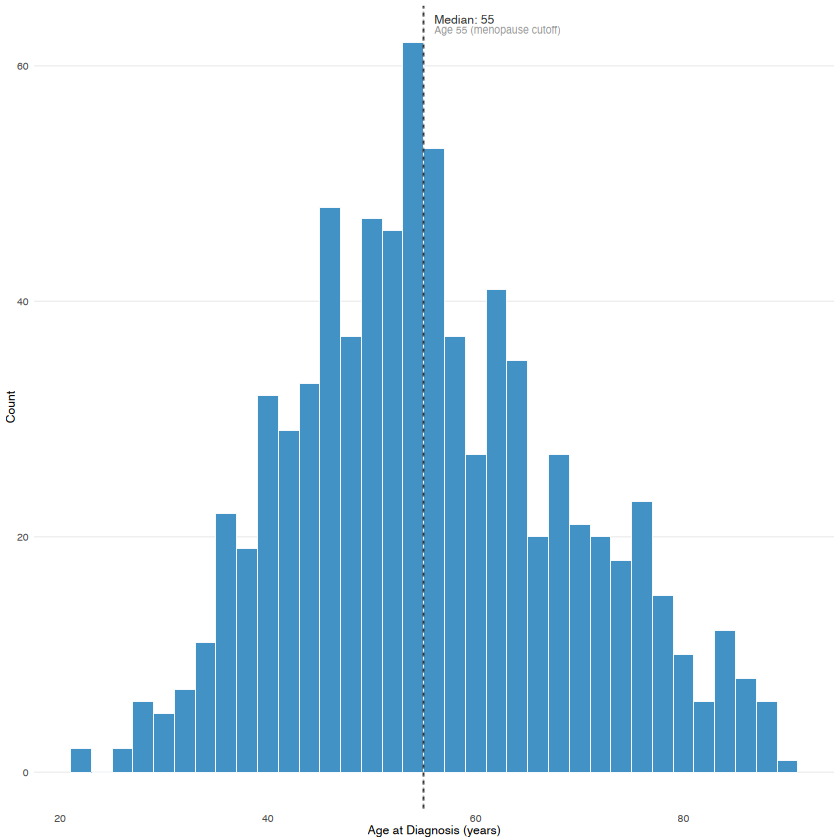

In [19]:
# ── Plot 1: Age at Diagnosis ──
plot_age <- function(df, base_size = BASE_TEXT_SIZE) {
  median_age <- median(df$age_at_dx, na.rm = TRUE)

  ggplot(df, aes(x = age_at_dx)) +
    geom_histogram(binwidth = 2, fill = "#4292c6", color = "white", linewidth = 0.2) +
    geom_vline(xintercept = median_age, linetype = "dashed", color = "#333333",
              linewidth = 0.4) +
    geom_vline(xintercept = 55, linetype = "dotted", color = "#999999",
              linewidth = 0.3) +
    annotate("text", x = median_age + 1, y = Inf, vjust = 2,
             label = paste0("Median: ", round(median_age, 1)),
             size = base_size / .pt, hjust = 0, color = "#333333") +
    annotate("text", x = 55 + 1, y = Inf, vjust = 3.5,
             label = "Age 55 (menopause cutoff)",
             size = (base_size - 1) / .pt, hjust = 0, color = "#999999") +
    labs(x = "Age at Diagnosis (years)", y = "Count") +
    theme_fig1(base_size)
}

p_age <- plot_age(df)
p_age
save_plot(p_age, "plot01_age")

Saved: plot02_bmi 


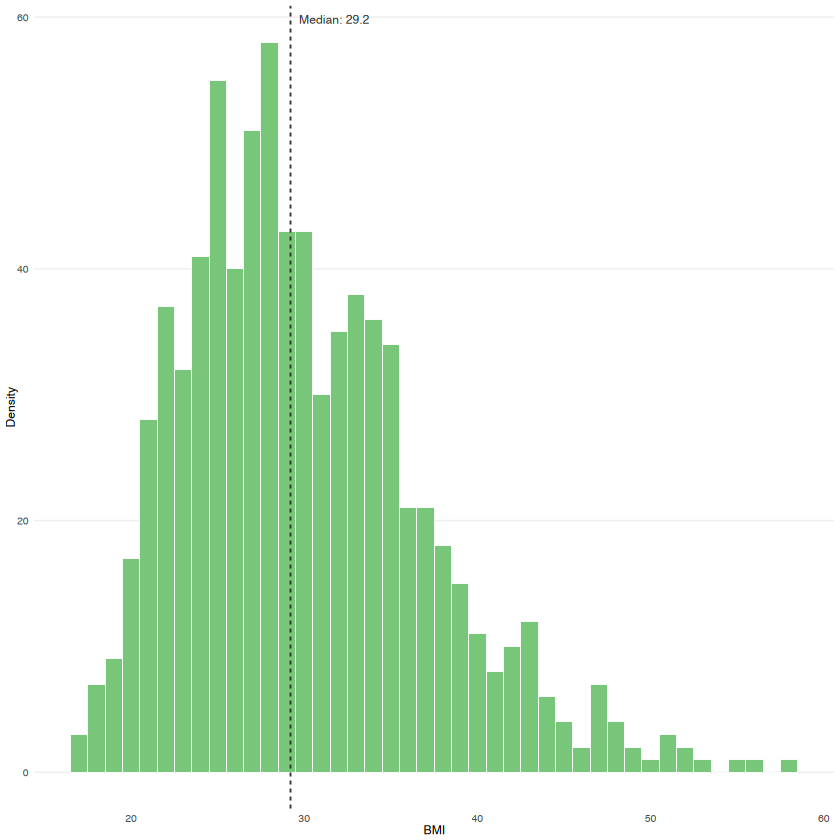

In [20]:
# ── Plot 2: BMI Distribution ──
plot_bmi <- function(df, base_size = BASE_TEXT_SIZE) {
  median_bmi <- median(df$bmi, na.rm = TRUE)

  ggplot(df, aes(x = bmi)) +
    geom_histogram(binwidth = 1, #aes(y = after_stat(density)), 
                   fill = "#78c679", color = "white", linewidth = 0.2) +
    # geom_density(color = "#31a354", linewidth = 0.5) +
    geom_vline(xintercept = median_bmi, linetype = "dashed", color = "#333333",
              linewidth = 0.4) +
    annotate("text", x = median_bmi + 0.5, y = Inf, vjust = 2,
             label = paste0("Median: ", round(median_bmi, 1)),
             size = base_size / .pt, hjust = 0, color = "#333333") +
    labs(x = expression("BMI"), y = "Density") +
    theme_fig1(base_size)
}

p_bmi <- plot_bmi(df)
p_bmi
save_plot(p_bmi, "plot02_bmi")

Saved: plot03_race 


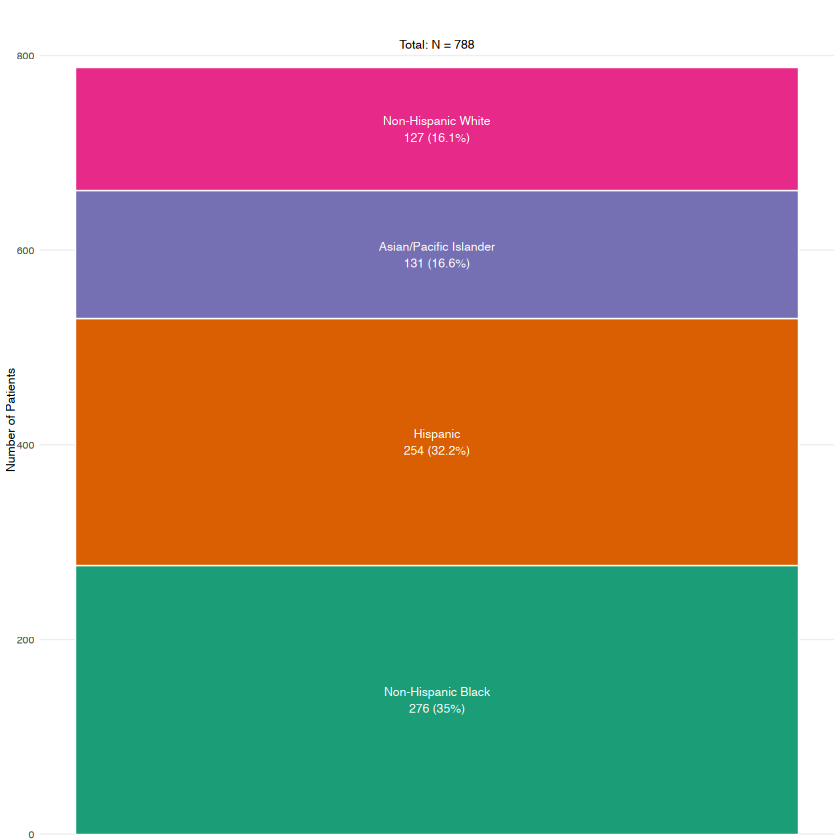

In [21]:
# ── Plot 3: Race / Ethnicity (vertical stacked bar with counts + percentages) ──
plot_race <- function(df, base_size = BASE_TEXT_SIZE) {
  N <- nrow(df)
  race_df <- df %>%
    count(race_ethnicity) %>%
    mutate(
      label = RACE_LABELS[race_ethnicity],
      label = ifelse(is.na(label), race_ethnicity, label)
    ) %>%
    arrange(desc(n)) %>%
    mutate(
      pct = round(n / N * 100, 1),
      bar_label = paste0(label, "\n", n, " (", pct, "%)"),
      ymax = cumsum(n),
      ymin = lag(ymax, default = 0),
      ymid = (ymin + ymax) / 2,
      label = factor(label, levels = rev(label))
    )

  ggplot(race_df, aes(xmin = 0, xmax = 1, ymin = ymin, ymax = ymax, fill = label)) +
    geom_rect(color = "white", linewidth = 0.3) +
    geom_text(aes(x = 0.5, y = ymid, label = bar_label),
              size = (base_size) / .pt, color = "white", fontface = "bold") +
    annotate("text", x = 0.5, y = N + N * 0.03,
             label = paste0("Total: N = ", N),
             size = base_size / .pt, fontface = "bold") +
    scale_fill_manual(values = PAL_RACE, guide = "none") +
    scale_y_continuous(expand = c(0, 0)) +
    coord_cartesian(ylim = c(0, N * 1.08), clip = "off") +
    labs(x = NULL, y = "Number of Patients") +
    theme_fig1(base_size) +
    theme(
      axis.text.x  = element_blank(),
      axis.ticks.x = element_blank(),
      panel.grid   = element_blank()
    )
}

p_race <- plot_race(df)
p_race
save_plot(p_race, "plot03_race", width = 60, height = 90)

## Clinical & Lifestyle

Saved: plot04_binary_vars 


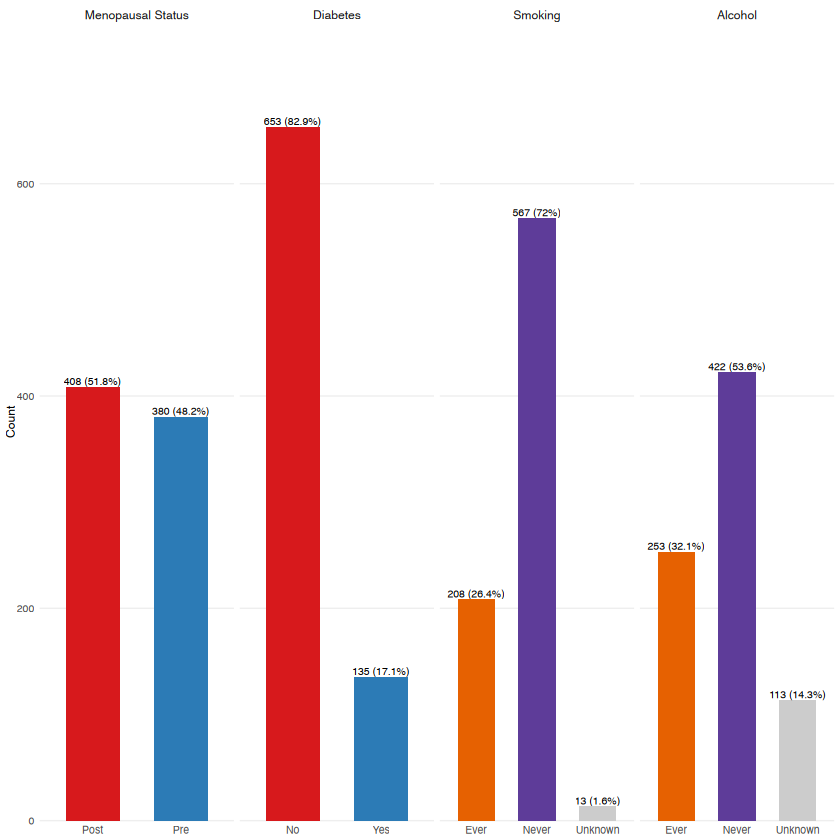

In [25]:
# ── Plot 4: Binary Variables (Menopausal, Diabetes, Smoking, Alcohol) ──
plot_binary_vars <- function(df, base_size = BASE_TEXT_SIZE) {
  bin_df <- df %>%
    transmute(
      `Menopausal Status` = menopausal_label,
      `Diabetes`          = diabetes_label,
      `Smoking`           = smoking_status_en,
      `Alcohol`           = alcohol_status_en
    ) %>%
    pivot_longer(everything(), names_to = "variable", values_to = "value") %>%
    mutate(variable = factor(variable,
      levels = c("Menopausal Status", "Diabetes", "Smoking", "Alcohol")))

  totals <- bin_df %>%
    count(variable, value) %>%
    group_by(variable) %>%
    mutate(pct = round(n / sum(n) * 100, 1),
           label = paste0(n, " (", pct, "%)")) %>%
    ungroup()

  ggplot(totals, aes(x = value, y = n, fill = value)) +
    geom_col(width = 0.6) +
    geom_text(aes(label = label), vjust = -0.3, size = (base_size - 1) / .pt) +
    facet_wrap(~ variable, scales = "free_x", nrow = 1) +
    scale_fill_manual(
      values = c("Pre" = "#2c7bb6", "Post" = "#d7191c",
                 "Yes" = "#2c7bb6", "No" = "#d7191c",
                 "Ever" = "#e66101", "Never" = "#5e3c99",
                 "Unknown" = "#cccccc"),
      guide = "none"
    ) +
    scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
    labs(x = NULL, y = "Count") +
    theme_fig1(base_size) +
    theme(panel.grid.major.x = element_blank())
}

p_binary <- plot_binary_vars(df)
p_binary
save_plot(p_binary, "plot04_binary_vars", width = 180, height = 60)

Saved: plot05_dxyear 


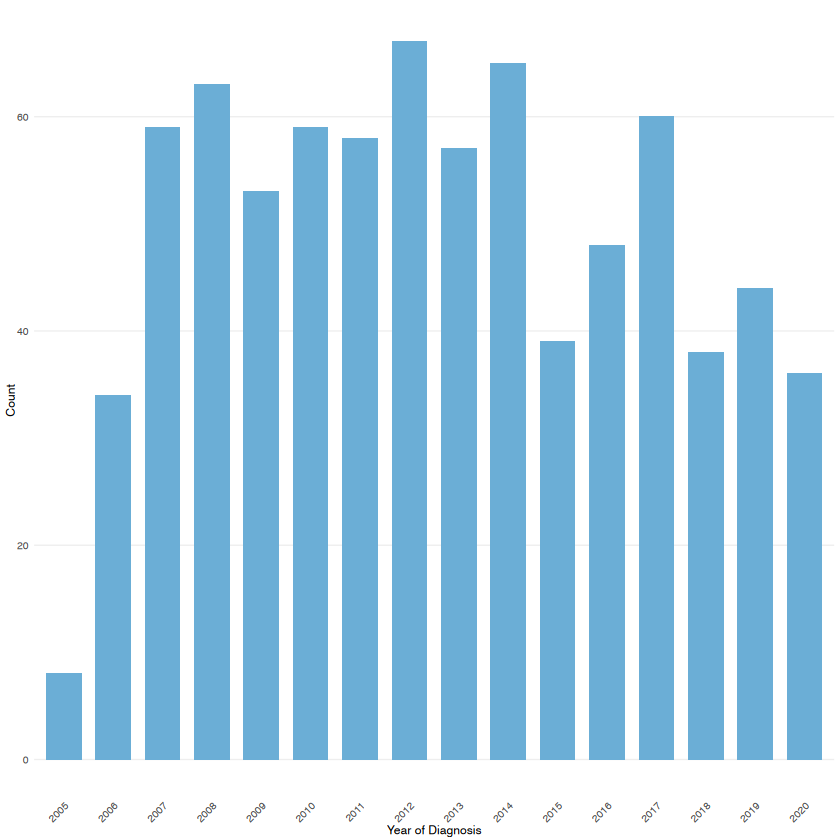

In [26]:
# ── Plot 5: Diagnosis Year ──
plot_dxyear <- function(df, base_size = BASE_TEXT_SIZE) {
  ggplot(df, aes(x = factor(dxyear))) +
    geom_bar(fill = "#6baed6", width = 0.7) +
    labs(x = "Year of Diagnosis", y = "Count") +
    theme_fig1(base_size) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

p_dxyear <- plot_dxyear(df)
p_dxyear
save_plot(p_dxyear, "plot05_dxyear")

## Tumor Characteristics

Saved: plot06_stage 


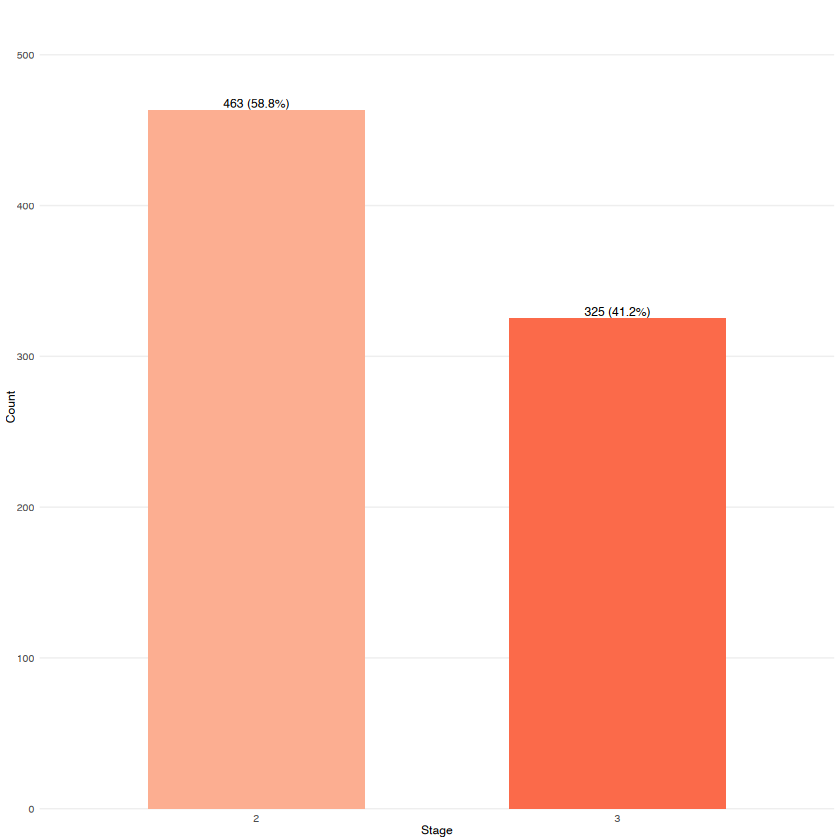

In [49]:
# ── Plot 6: Stage Distribution ──
plot_stage <- function(df, base_size = BASE_TEXT_SIZE) {
  stage_df <- df %>%
    count(stage) %>%
    mutate(pct = round(n / sum(n) * 100, 1),
           label = paste0(n, " (", pct, "%)"),
           stage = factor(stage))

  # Subset palette to observed stages
  pal <- PAL_STAGE[as.character(stage_df$stage)]

  ggplot(stage_df, aes(x = stage, y = n, fill = stage)) +
    geom_col(width = 0.6) +
    geom_text(aes(label = label), vjust = -0.3, size = base_size / .pt) +
    scale_fill_manual(values = pal, guide = "none") +
    scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
    labs(x = "Stage", y = "Count") +
    theme_fig1(base_size)
}

p_stage <- plot_stage(df)
p_stage
save_plot(p_stage, "plot06_stage")

Saved: plot07_grade 


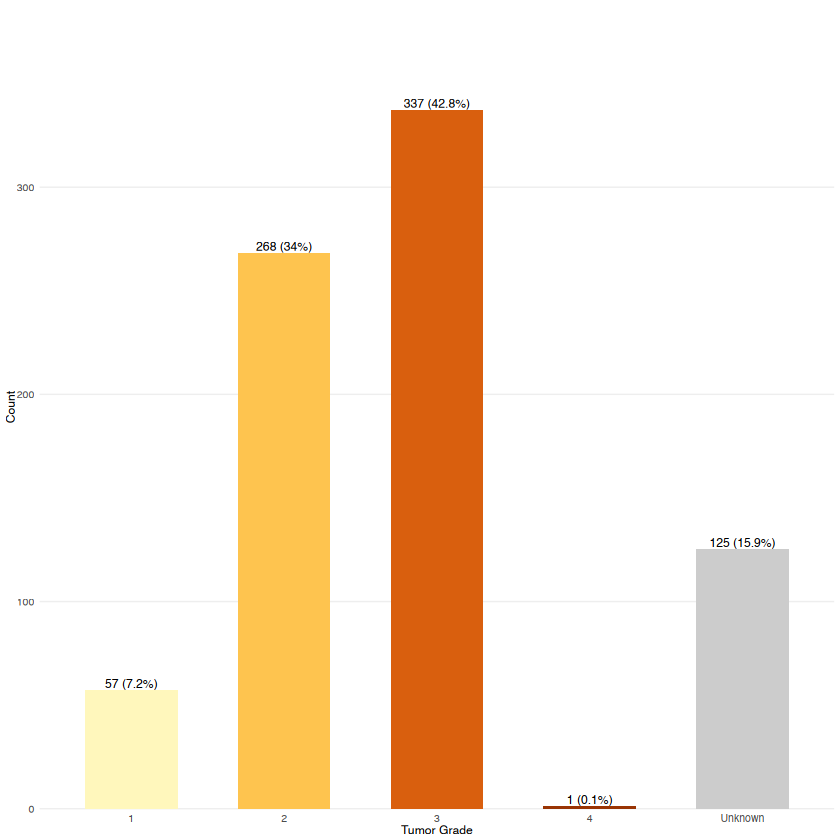

In [28]:
# ── Plot 7: Grade Distribution ──
plot_grade <- function(df, base_size = BASE_TEXT_SIZE) {
  grade_df <- df %>%
    count(grade_clean) %>%
    mutate(pct = round(n / sum(n) * 100, 1),
           label = paste0(n, " (", pct, "%)"),
           grade_clean = factor(grade_clean,
             levels = c("1", "2", "3", "4", "Unknown")))

  pal <- PAL_GRADE[as.character(grade_df$grade_clean)]

  ggplot(grade_df, aes(x = grade_clean, y = n, fill = grade_clean)) +
    geom_col(width = 0.6) +
    geom_text(aes(label = label), vjust = -0.3, size = base_size / .pt) +
    scale_fill_manual(values = pal, guide = "none") +
    scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
    labs(x = "Tumor Grade", y = "Count") +
    theme_fig1(base_size)
}

p_grade <- plot_grade(df)
p_grade
save_plot(p_grade, "plot07_grade")

Tumor size: excluding 8 patients with missing values
Saved: plot08_tumor_size 


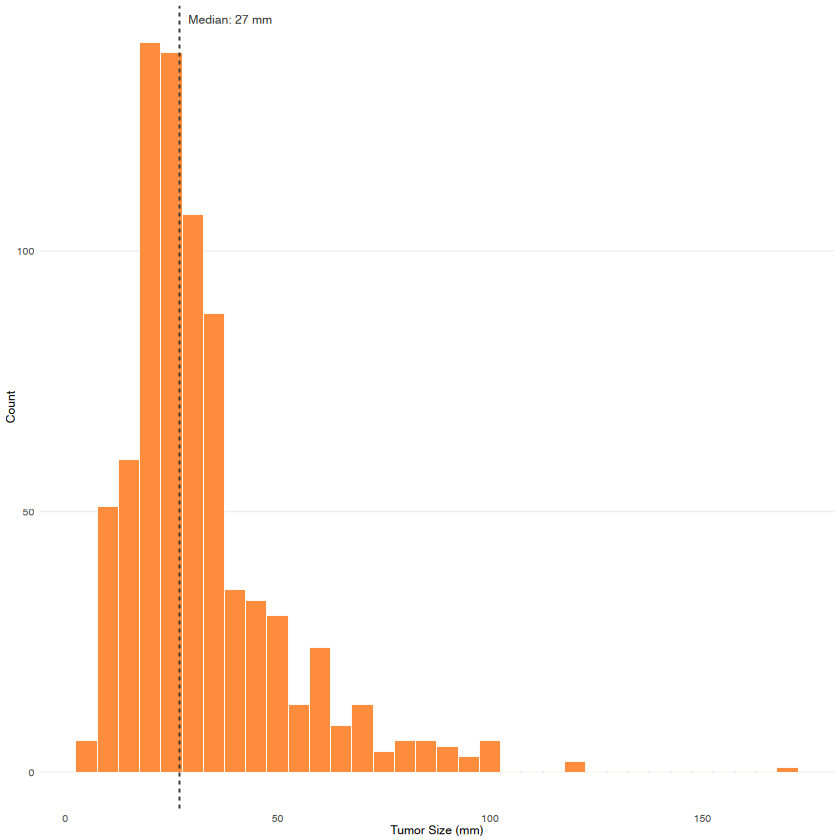

In [30]:
# ── Plot 8: Tumor Size ──
plot_tumor_size <- function(df, base_size = BASE_TEXT_SIZE) {
  n_na <- sum(is.na(df$tumor_size_mm))
  if (n_na > 0) cat("Tumor size: excluding", n_na, "patients with missing values\n")

  df_clean <- df %>% filter(!is.na(tumor_size_mm))
  median_size <- median(df_clean$tumor_size_mm, na.rm = TRUE)

  ggplot(df_clean, aes(x = tumor_size_mm)) +
    geom_histogram(binwidth = 5, fill = "#fd8d3c", color = "white", linewidth = 0.2) +
    geom_vline(xintercept = median_size, linetype = "dashed", color = "#333333",
              linewidth = 0.4) +
    annotate("text", x = median_size + 2, y = Inf, vjust = 2,
             label = paste0("Median: ", round(median_size, 0), " mm"),
             size = base_size / .pt, hjust = 0, color = "#333333") +
    labs(x = "Tumor Size (mm)", y = "Count") +
    theme_fig1(base_size)
}

p_tumor <- plot_tumor_size(df)
p_tumor
save_plot(p_tumor, "plot08_tumor_size")

Saved: plot09_receptor_tile 


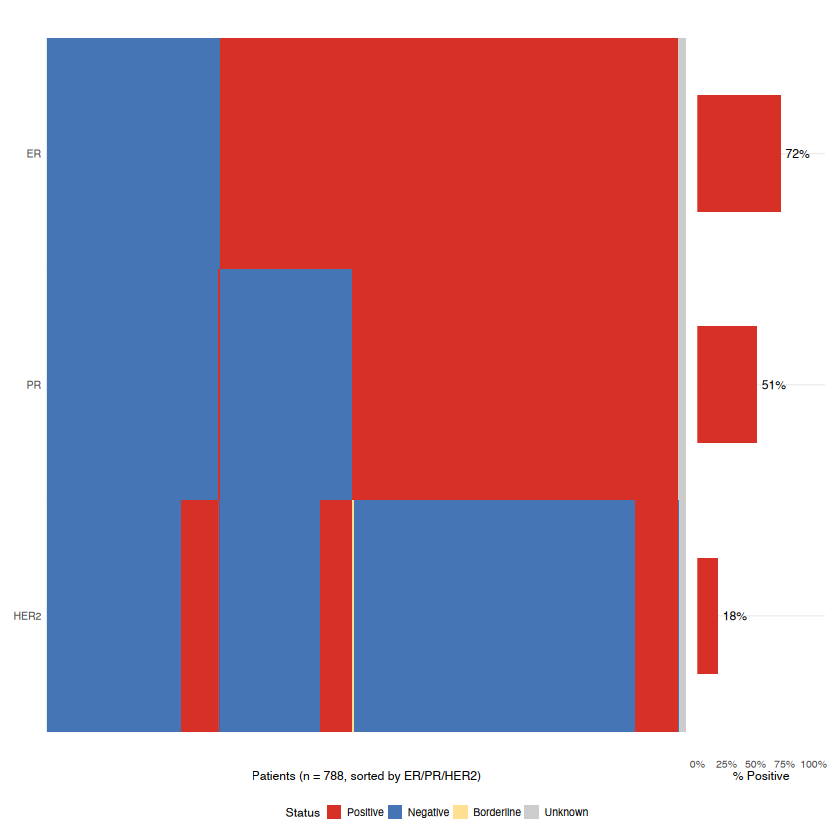

In [31]:
# ── Plot 9: Receptor Status Tile ──
plot_receptor_tile <- function(df, base_size = BASE_TEXT_SIZE) {
  # Sort patients by ER → PR → HER2 to create visual blocks
  tile_df <- df %>%
    arrange(er_status, pr_status, her2_status) %>%
    mutate(patient_idx = row_number()) %>%
    select(patient_idx, er_status, pr_status, her2_status) %>%
    pivot_longer(cols = c(er_status, pr_status, her2_status),
                 names_to = "receptor", values_to = "status") %>%
    mutate(
      receptor = factor(receptor,
        levels = c("her2_status", "pr_status", "er_status"),
        labels = c("HER2", "PR", "ER")),
      status = factor(status,
        levels = c("Positive", "Negative", "Borderline", "Unknown"))
    )

  # Main tile
  p_tile <- ggplot(tile_df, aes(x = patient_idx, y = receptor, fill = status)) +
    geom_tile(color = NA) +
    scale_fill_manual(values = PAL_RECEPTOR, na.value = "#cccccc", name = "Status") +
    scale_x_continuous(expand = c(0, 0)) +
    labs(x = paste0("Patients (n = ", nrow(df), ", sorted by ER/PR/HER2)"), y = NULL) +
    theme_fig1(base_size) +
    theme(
      axis.text.x  = element_blank(),
      axis.ticks.x = element_blank(),
      panel.grid   = element_blank(),
      legend.position = "bottom"
    )

  # Summary bar: % positive per receptor
  summary_df <- tile_df %>%
    group_by(receptor) %>%
    summarise(pct_pos = mean(status == "Positive", na.rm = TRUE), .groups = "drop")

  p_summary <- ggplot(summary_df, aes(x = pct_pos, y = receptor)) +
    geom_col(fill = PAL_RECEPTOR["Positive"], width = 0.5) +
    geom_text(aes(label = paste0(round(pct_pos * 100, 0), "%")),
              hjust = -0.2, size = base_size / .pt) +
    scale_x_continuous(labels = percent_format(), limits = c(0, 1),
                       expand = expansion(mult = c(0, 0.1))) +
    labs(x = "% Positive", y = NULL) +
    theme_fig1(base_size) +
    theme(axis.text.y = element_blank(),
          axis.ticks.y = element_blank(),
          panel.grid = element_blank())

  p_tile + p_summary + plot_layout(widths = c(5, 1), guides = "collect") &
    theme(legend.position = "bottom")
}

p_receptor <- plot_receptor_tile(df)
p_receptor
save_plot(p_receptor, "plot09_receptor_tile", width = 180, height = 60)

In [44]:
# ══════════════════════════════════════════════════════════
# Shared data prep for receptor plot variants (Options A & B)
# ══════════════════════════════════════════════════════════

# Desaturated palette (overrides default for these variants)
PAL_RECEPTOR2 <- c(
  "Positive"   = "#c0392b",   # soft red
  "Negative"   = "#5b8ec4",   # soft steel blue
  "Borderline" = "#f0c75e",   # muted gold
  "Unknown"    = "#bfbfbf"    # light grey
)

df_receptor <- df %>%
  mutate(
    ER   = er_status,
    PR   = pr_status,
    HER2 = her2_status,
    # Sorting keys: Positive = 1, Negative = 2, other = 3
    er_sort   = case_when(ER == "Positive" ~ 1, ER == "Negative" ~ 2, TRUE ~ 3),
    pr_sort   = case_when(PR == "Positive" ~ 1, PR == "Negative" ~ 2, TRUE ~ 3),
    her2_sort = case_when(HER2 == "Positive" ~ 1, HER2 == "Negative" ~ 2, TRUE ~ 3)
  ) %>%
  arrange(er_sort, pr_sort, her2_sort) %>%
  mutate(patient_rank = row_number())

cat("Receptor status summary (source:", RECEPTOR_SOURCE, ")\n")
cat("ER:  "); print(table(df_receptor$ER))
cat("PR:  "); print(table(df_receptor$PR))
cat("HER2:"); print(table(df_receptor$HER2))

Receptor status summary (source: path )
ER:  
Negative Positive  Unknown 
     214      565        9 
PR:  
Negative Positive  Unknown 
     375      404        9 
HER2:
Borderline   Negative   Positive    Unknown 
         3        638        139          8 


### Option A: Refined Patient-Level Tile Plot

Clean tile with `facet_grid` for row separation, no tile borders, desaturated palette, integrated summary bars.

Saved: plot09a_receptor_tile 


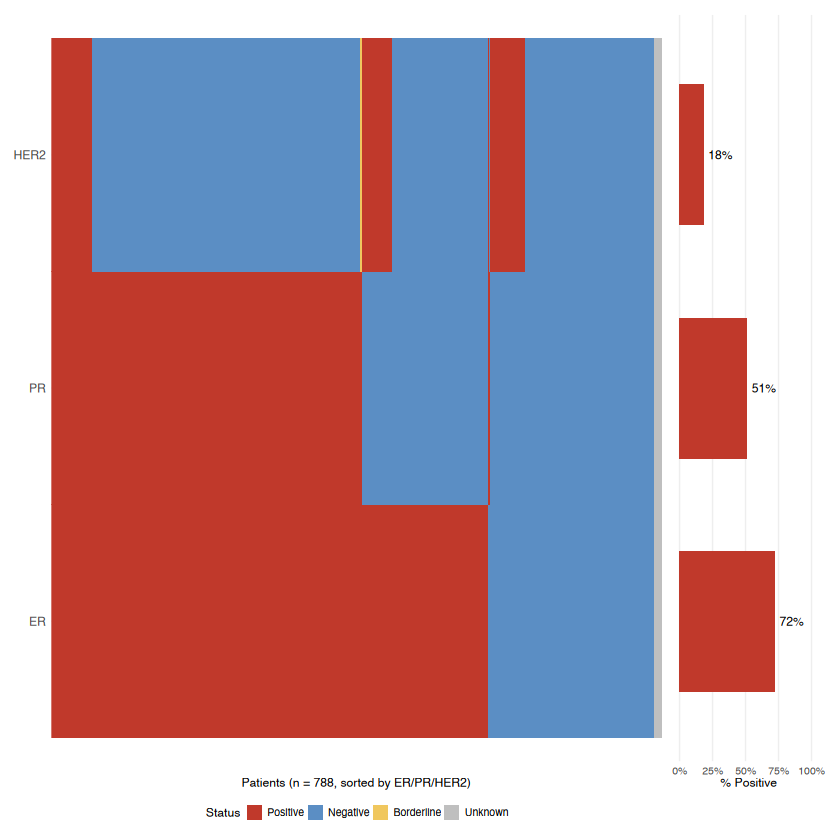

In [47]:
# ── Plot 9A: Refined Tile Plot ──

# Pivot to long format
df_tile <- df_receptor %>%
  select(patient_rank, ER, PR, HER2) %>%
  pivot_longer(cols = c(ER, PR, HER2), names_to = "receptor", values_to = "status") %>%
  mutate(
    receptor = factor(receptor, levels = c("ER", "PR", "HER2")),
    status   = factor(status, levels = c("Positive", "Negative", "Borderline", "Unknown"))
  )

# Tile plot — single panel, receptor on y-axis (no facet alignment issues)
p_tile_a <- ggplot(df_tile, aes(x = patient_rank, y = receptor, fill = status)) +
  geom_tile(color = NA, linewidth = 0) +
  scale_fill_manual(values = PAL_RECEPTOR2, name = "Status", drop = FALSE) +
  scale_x_continuous(expand = c(0, 0)) +
  labs(x = paste0("Patients (n = ", nrow(df_receptor), ", sorted by ER/PR/HER2)"), y = NULL) +
  theme_fig1() +
  theme(
    axis.text.x      = element_blank(),
    axis.ticks.x     = element_blank(),
    axis.text.y      = element_text(face = "bold", size = BASE_TEXT_SIZE),
    panel.grid       = element_blank(),
    legend.position  = "bottom",
    legend.direction = "horizontal"
  )

# Summary bars: % Positive per receptor (same y factor levels)
df_summary_a <- df_tile %>%
  group_by(receptor) %>%
  summarise(pct_positive = round(100 * mean(status == "Positive", na.rm = TRUE), 0),
            .groups = "drop")

p_summary_a <- ggplot(df_summary_a, aes(x = pct_positive, y = receptor)) +
  geom_col(fill = PAL_RECEPTOR2["Positive"], width = 0.6) +
  geom_text(aes(label = paste0(pct_positive, "%")), hjust = -0.2,
            size = BASE_TEXT_SIZE / .pt) +
  scale_x_continuous(limits = c(0, 105), breaks = c(0, 25, 50, 75, 100),
                     labels = c("0%", "25%", "50%", "75%", "100%")) +
  labs(x = "% Positive", y = NULL) +
  theme_fig1() +
  theme(
    axis.text.y        = element_blank(),
    axis.ticks.y       = element_blank(),
    panel.grid.major.x = element_line(color = "#eeeeee", linewidth = 0.3),
    panel.grid.major.y = element_blank()
  )

# Assemble — both share the same y factor, so rows align
p_receptor_a <- p_tile_a + p_summary_a +
  plot_layout(widths = c(4, 1))

p_receptor_a
save_plot(p_receptor_a, "plot09a_receptor_tile", width = 180, height = 70)

## Lymph Node Involvement

Node positivity: excluding 13 patients with missing data


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


Saved: plot10_node_pos 


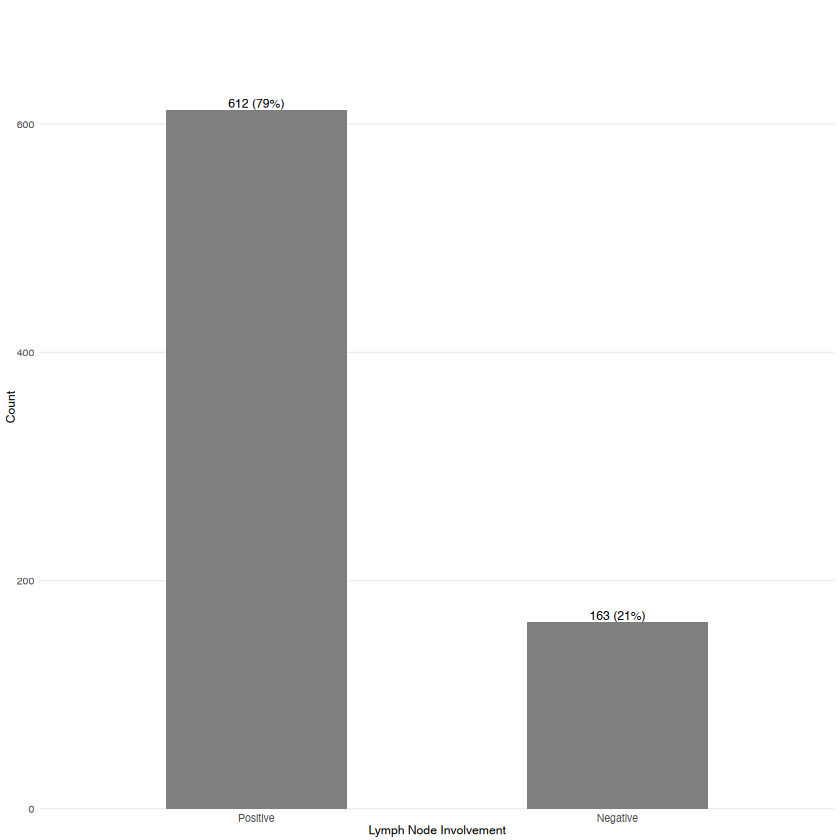

In [32]:
# ── Plot 10: Node Positivity Rate ──
plot_node_pos <- function(df, base_size = BASE_TEXT_SIZE) {
  n_na <- sum(is.na(df$node_positive))
  if (n_na > 0) cat("Node positivity: excluding", n_na, "patients with missing data\n")

  node_df <- df %>%
    filter(!is.na(node_positive)) %>%
    count(node_positive) %>%
    mutate(pct = round(n / sum(n) * 100, 1),
           label = paste0(n, " (", pct, "%)")
    )

  ggplot(node_df, aes(x = node_positive, y = n, fill = node_positive)) +
    geom_col(width = 0.5) +
    geom_text(aes(label = label), vjust = -0.3, size = base_size / .pt) +
    scale_fill_manual(values = PAL_BINARY, guide = "none") +
    scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
    labs(x = "Lymph Node Involvement", y = "Count") +
    theme_fig1(base_size)
}

p_node_pos <- plot_node_pos(df)
p_node_pos
save_plot(p_node_pos, "plot10_node_pos")

Positive nodes: using 771 patients ( 17 excluded)
Saved: plot11_nodes_count 


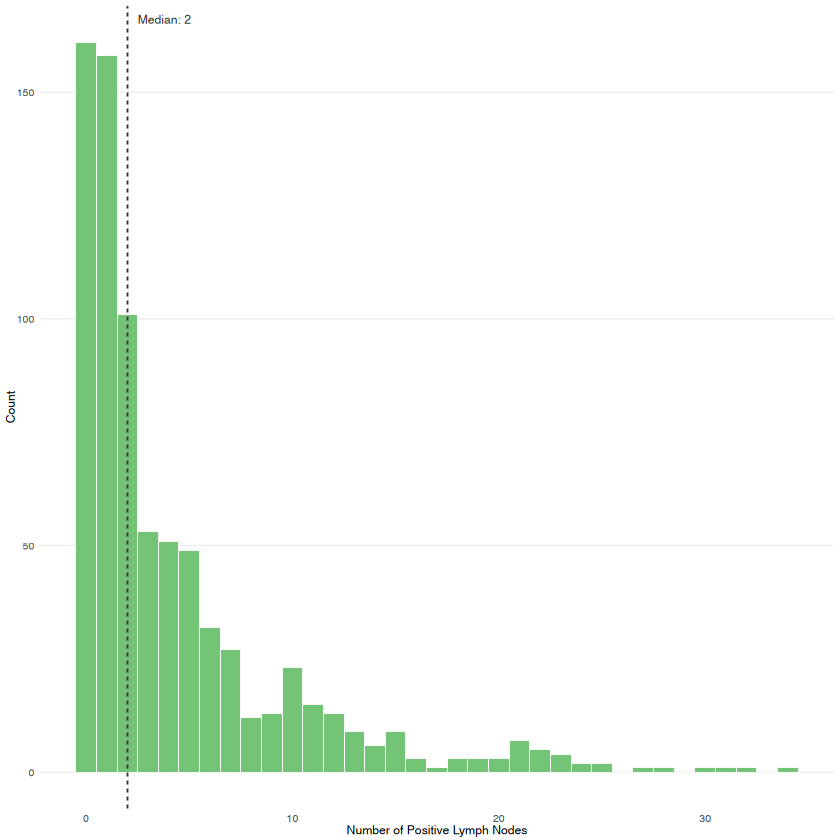

In [33]:
# ── Plot 11: Number of Positive Nodes ──
plot_nodes_count <- function(df, base_size = BASE_TEXT_SIZE) {
  df_clean <- df %>% filter(!is.na(reg_nodes_pos) & !is.na(reg_nodes_exam) & reg_nodes_exam > 0)
  n_excluded <- nrow(df) - nrow(df_clean)
  cat("Positive nodes: using", nrow(df_clean), "patients (", n_excluded, "excluded)\n")

  median_val <- median(df_clean$reg_nodes_pos, na.rm = TRUE)

  ggplot(df_clean, aes(x = reg_nodes_pos)) +
    geom_histogram(binwidth = 1, fill = "#74c476", color = "white", linewidth = 0.2) +
    geom_vline(xintercept = median_val, linetype = "dashed", color = "#333333",
              linewidth = 0.4) +
    annotate("text", x = median_val + 0.5, y = Inf, vjust = 2,
             label = paste0("Median: ", median_val),
             size = base_size / .pt, hjust = 0, color = "#333333") +
    labs(x = "Number of Positive Lymph Nodes", y = "Count") +
    theme_fig1(base_size)
}

p_nodes_count <- plot_nodes_count(df)
p_nodes_count
save_plot(p_nodes_count, "plot11_nodes_count")

Node ratio: using 771 patients ( 17 excluded)


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


Saved: plot12_node_ratio 


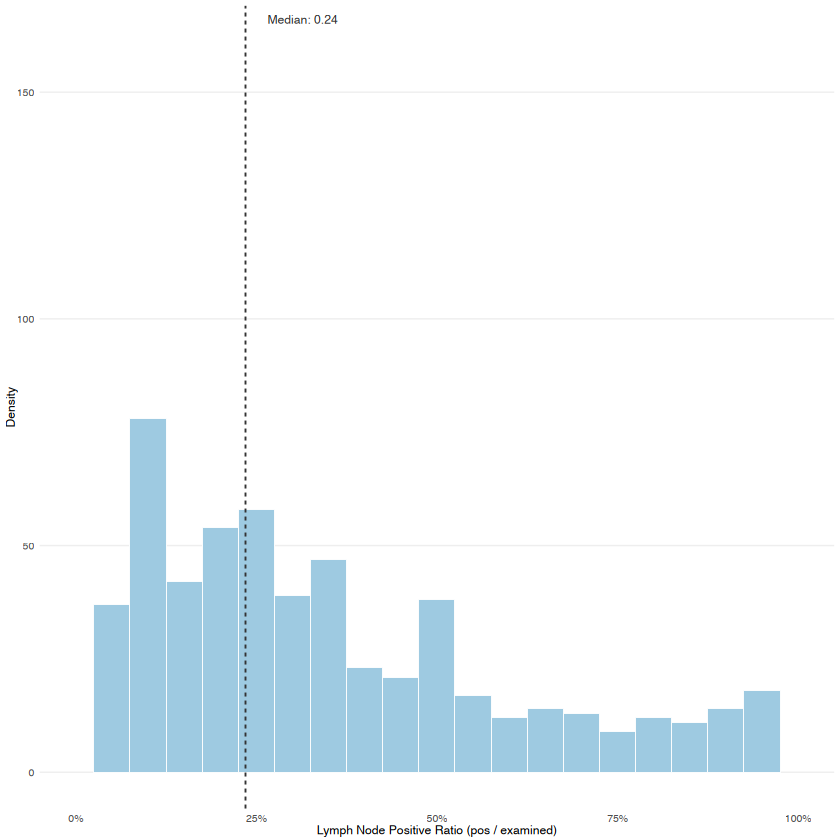

In [50]:
# ── Plot 12: Positive Node Ratio ──
plot_node_ratio <- function(df, base_size = BASE_TEXT_SIZE) {
  df_clean <- df %>% filter(!is.na(node_pos_ratio))
  n_excluded <- nrow(df) - nrow(df_clean)
  cat("Node ratio: using", nrow(df_clean), "patients (", n_excluded, "excluded)\n")

  median_ratio <- median(df_clean$node_pos_ratio, na.rm = TRUE)

  ggplot(df_clean, aes(x = node_pos_ratio)) +
    geom_histogram( binwidth = 0.05, #aes(y = after_stat(density)),
                   fill = "#9ecae1", color = "white", linewidth = 0.2) +
    # geom_density(color = "#3182bd", linewidth = 0.5) +
    geom_vline(xintercept = median_ratio, linetype = "dashed", color = "#333333",
              linewidth = 0.4) +
    annotate("text", x = median_ratio + 0.03, y = Inf, vjust = 2,
             label = paste0("Median: ", round(median_ratio, 2)),
             size = base_size / .pt, hjust = 0, color = "#333333") +
    scale_x_continuous(limits = c(0, 1), labels = percent_format()) +
    labs(x = "Lymph Node Positive Ratio (pos / examined)", y = "Density") +
    theme_fig1(base_size)
}

p_node_ratio <- plot_node_ratio(df)
p_node_ratio
save_plot(p_node_ratio, "plot12_node_ratio")

## Treatment

Saved: plot13_treatment_rates 


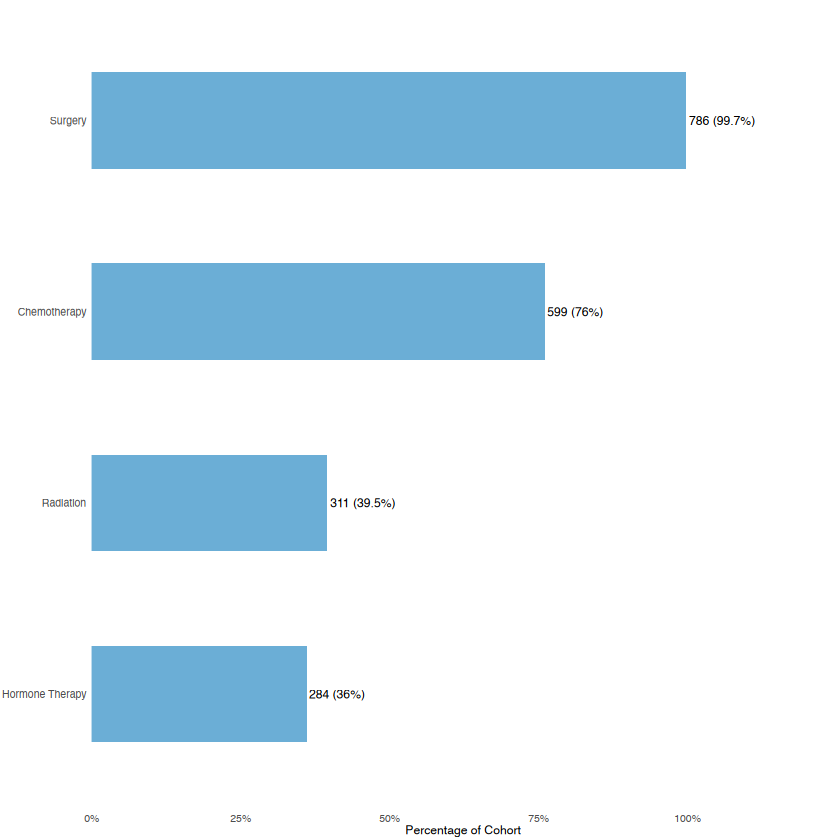

In [35]:
# ── Plot 13: Individual Treatment Rates ──
plot_treatment_rates <- function(df, base_size = BASE_TEXT_SIZE) {
  tx_map <- c(
    "received_chemo"   = "Chemotherapy",
    "received_rad"     = "Radiation",
    "received_horm"    = "Hormone Therapy",
    "received_surgery" = "Surgery"
  )

  tx_df <- data.frame(
    treatment = unname(tx_map),
    n         = sapply(names(tx_map), function(col) sum(df[[col]] == 1, na.rm = TRUE)),
    stringsAsFactors = FALSE
  ) %>%
    mutate(
      pct   = round(n / nrow(df) * 100, 1),
      label = paste0(n, " (", pct, "%)"),
      treatment = fct_reorder(treatment, n)
    )

  ggplot(tx_df, aes(x = treatment, y = pct / 100)) +
    geom_col(fill = "#6baed6", width = 0.5) +
    geom_text(aes(label = label), hjust = -0.05, size = base_size / .pt) +
    coord_flip() +
    scale_y_continuous(labels = percent_format(), expand = expansion(mult = c(0, 0.25))) +
    labs(x = NULL, y = "Percentage of Cohort") +
    theme_fig1(base_size) +
    theme(panel.grid.major.y = element_blank())
}

p_tx_rates <- plot_treatment_rates(df)
p_tx_rates
save_plot(p_tx_rates, "plot13_treatment_rates")

In [41]:
# ── Plot 14: Treatment Combination UpSet Plot ──
plot_treatment_upset <- function(df, base_size = BASE_TEXT_SIZE) {
  tx_labels <- c("Chemotherapy", "Radiation", "Hormone Therapy", "Surgery")
  tx_cols   <- c("received_chemo", "received_rad", "received_horm", "received_surgery")

  tx_df <- df %>% select(all_of(tx_cols))
  names(tx_df) <- tx_labels
  tx_df <- tx_df %>% mutate(across(everything(), as.logical))

  if (HAS_COMPLEXUPSET) {
    upset(
      tx_df, tx_labels,
      base_annotations = list(
        "Intersection size" = intersection_size(
          fill = "#6baed6"
        )
      ),
      min_size = 5,
      width_ratio = 0.3,
      set_sizes = upset_set_size() +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
    )
  } else {
    # ── Manual UpSet fallback ──
    tx_df$combo <- apply(tx_df, 1, function(r) {
      active <- tx_labels[r]
      if (length(active) == 0) return("None")
      paste(active, collapse = " + ")
    })

    combo_counts <- tx_df %>%
      count(combo) %>%
      filter(n >= 5) %>%
      arrange(desc(n))

    combo_order <- combo_counts$combo
    combo_counts$combo <- factor(combo_counts$combo, levels = rev(combo_order))

    # Bar chart
    p_bars <- ggplot(combo_counts, aes(x = combo, y = n)) +
      geom_col(fill = "#6baed6", width = 0.6) +
      geom_text(aes(label = n), hjust = -0.2, size = (base_size - 1) / .pt) +
      coord_flip() +
      scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
      labs(y = "Number of Patients", x = NULL) +
      theme_fig1(base_size) +
      theme(panel.grid.major.y = element_blank())

    # Dot matrix
    dot_data <- expand.grid(
      combo     = combo_order,
      treatment = tx_labels,
      stringsAsFactors = FALSE
    ) %>%
      rowwise() %>%
      mutate(active = grepl(treatment, combo, fixed = TRUE)) %>%
      ungroup() %>%
      mutate(combo = factor(combo, levels = rev(combo_order)),
             treatment_num = as.integer(factor(treatment, levels = tx_labels)))

    seg_data <- dot_data %>%
      filter(active) %>%
      group_by(combo) %>%
      summarise(ymin = min(treatment_num), ymax = max(treatment_num), .groups = "drop") %>%
      filter(ymin != ymax)

    p_dots <- ggplot(dot_data, aes(x = combo, y = treatment_num)) +
      geom_segment(data = seg_data,
                   aes(x = combo, xend = combo, y = ymin, yend = ymax),
                   linewidth = 0.5, color = "grey30") +
      geom_point(aes(color = active), size = 2) +
      scale_color_manual(values = c("TRUE" = "#333333", "FALSE" = "grey85"),
                         guide = "none") +
      scale_y_continuous(breaks = seq_along(tx_labels), labels = tx_labels) +
      coord_flip() +
      labs(x = NULL, y = NULL) +
      theme_fig1(base_size) +
      theme(panel.grid = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank())

    p_bars + p_dots + plot_layout(widths = c(3, 1))
  }
}

# p_upset <- plot_treatment_upset(df)
# p_upset
# save_plot(p_upset, "plot14_treatment_upset", width = 500, height = 100)

## Cross-Variable

Saved: plot15_stage_grade 


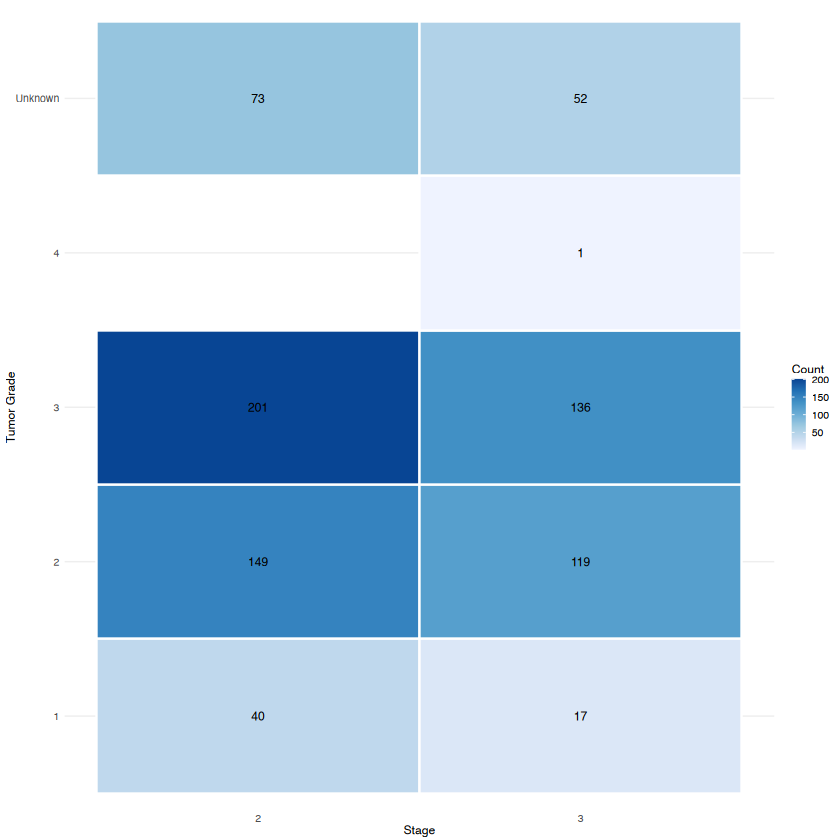

In [38]:
# ── Plot 15: Stage x Grade Crosstab ──
plot_stage_grade <- function(df, base_size = BASE_TEXT_SIZE) {
  cross_df <- df %>%
    count(stage, grade_clean) %>%
    mutate(grade_clean = factor(grade_clean,
      levels = c("1", "2", "3", "4", "Unknown")))

  ggplot(cross_df, aes(x = stage, y = grade_clean, fill = n)) +
    geom_tile(color = "white", linewidth = 0.5) +
    geom_text(aes(label = n), size = base_size / .pt, color = "black") +
    scale_fill_distiller(palette = "Blues", direction = 1, name = "Count") +
    labs(x = "Stage", y = "Tumor Grade") +
    theme_fig1(base_size) +
    theme(panel.grid = element_blank())
}

p_stage_grade <- plot_stage_grade(df)
p_stage_grade
save_plot(p_stage_grade, "plot15_stage_grade")

Saved: plot16_receptor_concordance 


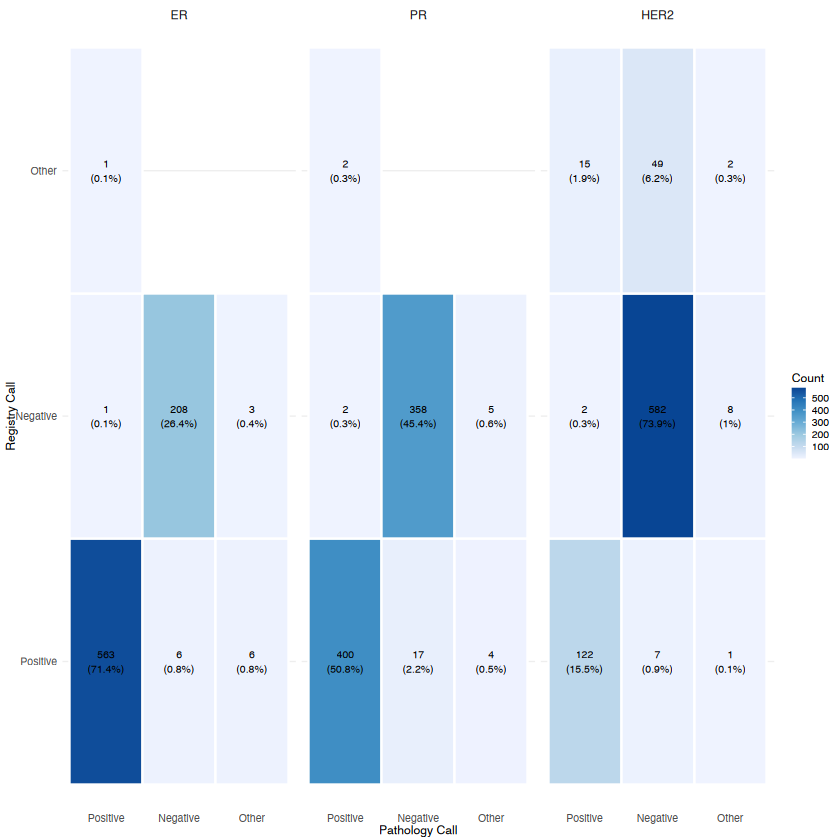

In [39]:
# ── Plot 16: Receptor Concordance (Registry vs Pathology) ──
plot_receptor_concordance <- function(df, base_size = BASE_TEXT_SIZE) {
  receptors <- c("ER" = "er_status", "PR" = "pr_status", "HER2" = "her2_status")

  conc_list <- lapply(names(receptors), function(rec) {
    reg_col  <- paste0(receptors[rec], "_registry")
    path_col <- paste0(receptors[rec], "_path")

    df %>%
      transmute(
        receptor  = rec,
        Registry  = recode_receptor(.data[[reg_col]]),
        Pathology = recode_receptor(.data[[path_col]])
      )
  })
  conc_df <- do.call(rbind, conc_list)

  # Simplify to Positive/Negative/Other for cleaner 2x2
  simplify_status <- function(x) {
    ifelse(x %in% c("Positive", "Negative"), x, "Other")
  }
  conc_df$Registry  <- simplify_status(conc_df$Registry)
  conc_df$Pathology <- simplify_status(conc_df$Pathology)

  conc_df$Registry  <- factor(conc_df$Registry,  levels = c("Positive", "Negative", "Other"))
  conc_df$Pathology <- factor(conc_df$Pathology, levels = c("Positive", "Negative", "Other"))
  conc_df$receptor  <- factor(conc_df$receptor, levels = c("ER", "PR", "HER2"))

  tile_data <- conc_df %>%
    count(receptor, Registry, Pathology) %>%
    group_by(receptor) %>%
    mutate(pct = round(n / sum(n) * 100, 1),
           label = paste0(n, "\n(", pct, "%)")) %>%
    ungroup()

  ggplot(tile_data, aes(x = Pathology, y = Registry, fill = n)) +
    geom_tile(color = "white", linewidth = 0.5) +
    geom_text(aes(label = label), size = (base_size - 1) / .pt, color = "black") +
    facet_wrap(~ receptor, nrow = 1) +
    scale_fill_distiller(palette = "Blues", direction = 1, name = "Count") +
    labs(x = "Pathology Call", y = "Registry Call") +
    theme_fig1(base_size) +
    theme(panel.grid = element_blank())
}

p_concordance <- plot_receptor_concordance(df)
p_concordance
save_plot(p_concordance, "plot16_receptor_concordance", width = 180, height = 70)

## Combined PDF Report

In [51]:
# ── All plots in a single PDF, one per page ──
if (SAVE_PLOTS) {
  pdf_path <- file.path(OUTPUT_DIR, "all_plots.pdf")
  pdf(pdf_path, width = 7, height = 5)

  print(p_age)
  print(p_bmi)
  print(p_race)
  print(p_binary)
  print(p_dxyear)
  print(p_stage)
  print(p_grade)
  print(p_tumor)
  print(p_receptor_a)
  print(p_node_pos)
  print(p_nodes_count)
  print(p_node_ratio)
  print(p_tx_rates)
  # print(p_upset)
  print(p_stage_grade)
  print(p_concordance)

  dev.off()
  cat("Combined PDF saved to:", pdf_path, "\n")
}

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


Combined PDF saved to: ../outputs/METADATA/figures/all_plots.pdf 


In [52]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-apple-darwin13.4.0
Running under: macOS Tahoe 26.2

Matrix products: default
BLAS/LAPACK: /Users/fs2829/miniforge3/envs/COSMX_RNA_env_proj_ADANA/lib/libopenblasp-r0.3.30.dylib;  LAPACK version 3.12.0

locale:
[1] C/C.UTF-8/C/C/C/C

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] forcats_1.0.1   scales_1.4.0    patchwork_1.3.2 ggplot2_4.0.1  
[5] tidyr_1.3.2     dplyr_1.1.4    

loaded via a namespace (and not attached):
 [1] gtable_0.3.6       jsonlite_2.0.0     compiler_4.5.2     crayon_1.5.3      
 [5] tidyselect_1.2.1   IRdisplay_1.1      dichromat_2.0-0.1  systemfonts_1.3.1 
 [9] textshaping_1.0.4  uuid_1.2-1         fastmap_1.2.0      IRkernel_1.3.2    
[13] R6_2.6.1           labeling_0.4.3     generics_0.1.4     Cairo_1.6-5       
[17] tibble_3.3.1       pillar_1.11.1      RColorBrewer_1.1-3 rlang